In [3]:
import pandas as pd
df=pd.read_csv("DataCoSupplyChainDataset.csv",encoding='ISO-8859-1')

In [4]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


In [5]:
# Display the first few rows to verify the data load
print("=== First 5 Rows of Supply Chain Dataset ===")
print(df.head())

=== First 5 Rows of Supply Chain Dataset ===
       Type  Days for shipping (real)  Days for shipment (scheduled)  \
0     DEBIT                         3                              4   
1  TRANSFER                         5                              4   
2      CASH                         4                              4   
3     DEBIT                         3                              4   
4   PAYMENT                         2                              4   

   Benefit per order  Sales per customer   Delivery Status  \
0          91.250000          314.640015  Advance shipping   
1        -249.089996          311.359985     Late delivery   
2        -247.779999          309.720001  Shipping on time   
3          22.860001          304.809998  Advance shipping   
4         134.210007          298.250000  Advance shipping   

   Late_delivery_risk  Category Id   Category Name Customer City  ...  \
0                   0           73  Sporting Goods        Caguas  ...   
1  

In [6]:
print("\n=== Missing Values Count ===")
missing_values = df.isnull().sum()
print(missing_values)


=== Missing Values Count ===
Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market    

In [7]:
def features_with_missing_values(data):
    x = data.isnull().sum().sum()/(data.shape[0]*data.shape[1])*100
    print('Percentage of Total Missing Values is ' ,round(x,2) ,'%')
    print('Missing Value Estimation :')
    for i in data.columns:
        if data[i].isna().sum()>0:
            print('The Feature ',i,' has '+ str(data[i].isna().sum()) + ' missing values')
            
features_with_missing_values(df)

Percentage of Total Missing Values is  3.51 %
Missing Value Estimation :
The Feature  Customer Lname  has 8 missing values
The Feature  Customer Zipcode  has 3 missing values
The Feature  Order Zipcode  has 155679 missing values
The Feature  Product Description  has 180519 missing values


In [8]:
print(f"Dataset rows: {df.shape[0]}")
print(f"Dataset columns: {df.shape[1]}")

Dataset rows: 180519
Dataset columns: 53


In [9]:
modeling_columns = ['Type',
                  'Days for shipping (real)', 
                  'Days for shipment (scheduled)',
                  'Benefit per order',
                  'Sales per customer',
                  'Latitude',
                  'Longitude',
                  'Order Item Discount',
                  'Order Item Discount Rate',
                  'Order Item Total',
                  'Order Profit Per Order',
                  'Order Status',
                  'Shipping Mode',
                  'Late_delivery_risk']

In [10]:
len(modeling_columns)

14

In [11]:
def drop_columns(dataset, columns_to_drop):
    dataset = dataset.drop(columns=columns_to_drop)
    print(f"{len(columns_to_drop)} columns dropped successfully. Number of columns remaining: {len(dataset.columns)}")
    return dataset

In [12]:
columns_to_drop = [col for col in df.columns if col not in modeling_columns]

In [13]:
len(columns_to_drop)

39

In [14]:
df1=drop_columns(df,columns_to_drop)

39 columns dropped successfully. Number of columns remaining: 14


In [15]:
print(f"Dataset rows: {df1.shape[0]}")
print(f"Dataset columns: {df1.shape[1]}")

Dataset rows: 180519
Dataset columns: 14


In [16]:
df1

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Latitude,Longitude,Order Item Discount,Order Item Discount Rate,Order Item Total,Order Profit Per Order,Order Status,Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,0,18.251453,-66.037056,13.110000,0.04,314.640015,91.250000,COMPLETE,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,1,18.279451,-66.037064,16.389999,0.05,311.359985,-249.089996,PENDING,Standard Class
2,CASH,4,4,-247.779999,309.720001,0,37.292233,-121.881279,18.030001,0.06,309.720001,-247.779999,CLOSED,Standard Class
3,DEBIT,3,4,22.860001,304.809998,0,34.125946,-118.291016,22.940001,0.07,304.809998,22.860001,COMPLETE,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,0,18.253769,-66.037048,29.500000,0.09,298.250000,134.210007,PENDING_PAYMENT,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,0,40.640930,-73.942711,0.000000,0.00,399.980011,40.000000,CLOSED,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,1,35.362545,-119.018700,4.000000,0.01,395.980011,-613.770019,COMPLETE,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,1,41.629959,-72.967155,8.000000,0.02,391.980011,141.110001,PENDING,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,0,18.213350,-66.370575,12.000000,0.03,387.980011,186.229996,PENDING_PAYMENT,Standard Class


In [17]:
df1.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Late_delivery_risk',
       'Latitude', 'Longitude', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Total',
       'Order Profit Per Order', 'Order Status', 'Shipping Mode'],
      dtype='object')

In [18]:
# check null values
df1.isna().sum()

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Late_delivery_risk               0
Latitude                         0
Longitude                        0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Total                 0
Order Profit Per Order           0
Order Status                     0
Shipping Mode                    0
dtype: int64

In [19]:
#analyze categorical columns 
categorical_cols = df1.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_cols:
   unique_values = df1[col].unique()
   num_unique = len(unique_values)
   print(f"\nColumn: {col}")
   print(f"Number of unique values: {num_unique}")
   #print("Unique values:")
   #print(unique_values)


Column: Type
Number of unique values: 4

Column: Order Status
Number of unique values: 9

Column: Shipping Mode
Number of unique values: 4


In [20]:
df1.duplicated().sum()

4

In [21]:
df1[df1.duplicated()]

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Latitude,Longitude,Order Item Discount,Order Item Discount Rate,Order Item Total,Order Profit Per Order,Order Status,Shipping Mode
94789,DEBIT,5,4,53.230000,118.290001,1,28.102118,-82.512115,11.7,0.09,118.290001,53.230000,COMPLETE,Standard Class
137818,PAYMENT,2,4,138.589996,395.980011,0,21.287289,-157.671402,4.0,0.01,395.980011,138.589996,PENDING_PAYMENT,Standard Class
146875,DEBIT,2,2,93.599998,359.980011,0,29.780575,-95.171997,40.0,0.10,359.980011,93.599998,COMPLETE,Second Class
175279,DEBIT,2,1,120.949997,335.980011,1,18.380119,-66.183128,64.0,0.16,335.980011,120.949997,COMPLETE,First Class


In [22]:
df1=df1.drop_duplicates()

In [23]:
df1

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Latitude,Longitude,Order Item Discount,Order Item Discount Rate,Order Item Total,Order Profit Per Order,Order Status,Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,0,18.251453,-66.037056,13.110000,0.04,314.640015,91.250000,COMPLETE,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,1,18.279451,-66.037064,16.389999,0.05,311.359985,-249.089996,PENDING,Standard Class
2,CASH,4,4,-247.779999,309.720001,0,37.292233,-121.881279,18.030001,0.06,309.720001,-247.779999,CLOSED,Standard Class
3,DEBIT,3,4,22.860001,304.809998,0,34.125946,-118.291016,22.940001,0.07,304.809998,22.860001,COMPLETE,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,0,18.253769,-66.037048,29.500000,0.09,298.250000,134.210007,PENDING_PAYMENT,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,0,40.640930,-73.942711,0.000000,0.00,399.980011,40.000000,CLOSED,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,1,35.362545,-119.018700,4.000000,0.01,395.980011,-613.770019,COMPLETE,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,1,41.629959,-72.967155,8.000000,0.02,391.980011,141.110001,PENDING,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,0,18.213350,-66.370575,12.000000,0.03,387.980011,186.229996,PENDING_PAYMENT,Standard Class


In [24]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Type','Order Status', 'Shipping Mode']
le = LabelEncoder()
for col in categorical_cols:
    df1[col] = le.fit_transform(df1[col])

C:\Users\cstd\AppData\Local\Temp\ipykernel_7208\2977665707.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1[col] = le.fit_transform(df1[col])
C:\Users\cstd\AppData\Local\Temp\ipykernel_7208\2977665707.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1[col] = le.fit_transform(df1[col])
C:\Users\cstd\AppData\Local\Temp\ipykernel_7208\2977665707.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead



In [25]:
df1

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Latitude,Longitude,Order Item Discount,Order Item Discount Rate,Order Item Total,Order Profit Per Order,Order Status,Shipping Mode
0,1,3,4,91.250000,314.640015,0,18.251453,-66.037056,13.110000,0.04,314.640015,91.250000,2,3
1,3,5,4,-249.089996,311.359985,1,18.279451,-66.037064,16.389999,0.05,311.359985,-249.089996,5,3
2,0,4,4,-247.779999,309.720001,0,37.292233,-121.881279,18.030001,0.06,309.720001,-247.779999,1,3
3,1,3,4,22.860001,304.809998,0,34.125946,-118.291016,22.940001,0.07,304.809998,22.860001,2,3
4,2,2,4,134.210007,298.250000,0,18.253769,-66.037048,29.500000,0.09,298.250000,134.210007,6,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,0,4,4,40.000000,399.980011,0,40.640930,-73.942711,0.000000,0.00,399.980011,40.000000,1,3
180515,1,3,2,-613.770019,395.980011,1,35.362545,-119.018700,4.000000,0.01,395.980011,-613.770019,2,2
180516,3,5,4,141.110001,391.980011,1,41.629959,-72.967155,8.000000,0.02,391.980011,141.110001,5,3
180517,2,3,4,186.229996,387.980011,0,18.213350,-66.370575,12.000000,0.03,387.980011,186.229996,6,3


In [26]:
X = df1.drop(columns=['Late_delivery_risk'])  # features
y = df1['Late_delivery_risk']                 # target

In [27]:
X

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Latitude,Longitude,Order Item Discount,Order Item Discount Rate,Order Item Total,Order Profit Per Order,Order Status,Shipping Mode
0,1,3,4,91.250000,314.640015,18.251453,-66.037056,13.110000,0.04,314.640015,91.250000,2,3
1,3,5,4,-249.089996,311.359985,18.279451,-66.037064,16.389999,0.05,311.359985,-249.089996,5,3
2,0,4,4,-247.779999,309.720001,37.292233,-121.881279,18.030001,0.06,309.720001,-247.779999,1,3
3,1,3,4,22.860001,304.809998,34.125946,-118.291016,22.940001,0.07,304.809998,22.860001,2,3
4,2,2,4,134.210007,298.250000,18.253769,-66.037048,29.500000,0.09,298.250000,134.210007,6,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,0,4,4,40.000000,399.980011,40.640930,-73.942711,0.000000,0.00,399.980011,40.000000,1,3
180515,1,3,2,-613.770019,395.980011,35.362545,-119.018700,4.000000,0.01,395.980011,-613.770019,2,2
180516,3,5,4,141.110001,391.980011,41.629959,-72.967155,8.000000,0.02,391.980011,141.110001,5,3
180517,2,3,4,186.229996,387.980011,18.213350,-66.370575,12.000000,0.03,387.980011,186.229996,6,3


In [28]:
y

0         0
1         1
2         0
3         0
4         0
         ..
180514    0
180515    1
180516    1
180517    0
180518    0
Name: Late_delivery_risk, Length: 180515, dtype: int64

In [29]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [30]:
X_scaled

array([[0.33333333, 0.5       , 1.        , ..., 0.84179973, 0.25      ,
        1.        ],
       [1.        , 0.83333333, 1.        , ..., 0.77618291, 0.625     ,
        1.        ],
       [0.        , 0.66666667, 1.        , ..., 0.77643548, 0.125     ,
        1.        ],
       ...,
       [1.        , 0.83333333, 1.        , ..., 0.85141263, 0.625     ,
        1.        ],
       [0.66666667, 0.5       , 1.        , ..., 0.86011167, 0.75      ,
        1.        ],
       [0.66666667, 0.66666667, 1.        , ..., 0.85678012, 0.75      ,
        1.        ]])

In [31]:
X_scaled.shape

(180515, 13)

In [32]:
import numpy as np
X_lstm = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

In [33]:
X_lstm.shape 

(180515, 1, 13)

In [34]:
X.shape[1]

13

In [35]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, Dropout

def feature_extraction(input_shape):
    inputs = Input(shape=input_shape)

    # Deep BiLSTM stack
    x = Bidirectional(LSTM(128, return_sequences=True))(inputs)
    x = Dropout(0.3)(x)

    x = Bidirectional(LSTM(64, return_sequences=False))(x)
    x = Dropout(0.3)(x)

    # Fully connected layers for feature compression
    x = Dense(64, activation='relu')(x)
    x = Dense(32, activation='relu')(x)

    # Final output is the feature vector
    model = Model(inputs=inputs, outputs=x)
    return model


In [36]:
input_shape = (1, X.shape[1])
model=feature_extraction(input_shape)

In [37]:
model

In [38]:
model.compile(optimizer='adam',loss='mean_squared_error')

In [39]:
X_features = model.predict(X_lstm)
print(X_features.shape) 

5642/5642 [==============================] - 11s 2ms/step
(180515, 32)


In [40]:
X_features

array([[0.        , 0.00348759, 0.        , ..., 0.00084618, 0.01732268,
        0.        ],
       [0.        , 0.00534297, 0.        , ..., 0.00185442, 0.01796373,
        0.        ],
       [0.        , 0.00303522, 0.        , ..., 0.00112164, 0.01486436,
        0.        ],
       ...,
       [0.        , 0.00402358, 0.        , ..., 0.00250486, 0.01858144,
        0.        ],
       [0.        , 0.00353997, 0.        , ..., 0.00157108, 0.0179825 ,
        0.        ],
       [0.        , 0.00434866, 0.        , ..., 0.00168657, 0.01820021,
        0.        ]], dtype=float32)

In [41]:
y.shape

(180515,)

In [42]:
#np.save("deeper_BiLSTM_32",X_features)

In [43]:
from sklearn.model_selection import train_test_split
X_train,X_remaining ,y_train ,y_remaining=train_test_split(X_features,y,test_size=0.4,random_state=42)

#spliting the remaining data into testing and validation 

X_val,X_test,y_val,y_test=train_test_split(X_remaining ,y_remaining , test_size=0.5,random_state=42)

In [44]:
X_train.shape, X_val.shape ,X_test.shape , y_train.shape, y_val.shape ,y_test.shape 

((108309, 32), (36103, 32), (36103, 32), (108309,), (36103,), (36103,))

In [45]:
X_train.shape, X_test.shape,X_val.shape

((108309, 32), (36103, 32), (36103, 32))

In [46]:
#softmax regression

In [47]:
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score
softmax_model=LogisticRegression(max_iter=1000 , multi_class='multinomial')
history=softmax_model.fit(X_train , y_train)

C:\Users\cstd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


In [48]:
##for loss 

In [49]:
'''from sklearn.linear_model import LogisticRegression
import numpy as np

losses = []
model = LogisticRegression(max_iter=1, warm_start=True, solver='lbfgs', multi_class='multinomial')

for i in range(20):  # simulate 20 epochs
    model.fit(X_train, y_train)
    
    # Compute log loss manually
    probas = model.predict_proba(X_train)
    
    # Use log loss from sklearn
    from sklearn.metrics import log_loss
    loss = log_loss(y_train, probas)
    losses.append(loss)

# Plot loss manually
import matplotlib.pyplot as plt
plt.plot(range(1, 21), losses, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.title('Simulated Loss Curve (LogisticRegression)')
plt.legend()
plt.grid(True)
plt.show()'''


"from sklearn.linear_model import LogisticRegression\nimport numpy as np\n\nlosses = []\nmodel = LogisticRegression(max_iter=1, warm_start=True, solver='lbfgs', multi_class='multinomial')\n\nfor i in range(20):  # simulate 20 epochs\n    model.fit(X_train, y_train)\n    \n    # Compute log loss manually\n    probas = model.predict_proba(X_train)\n    \n    # Use log loss from sklearn\n    from sklearn.metrics import log_loss\n    loss = log_loss(y_train, probas)\n    losses.append(loss)\n\n# Plot loss manually\nimport matplotlib.pyplot as plt\nplt.plot(range(1, 21), losses, label='Train Loss')\nplt.xlabel('Epoch')\nplt.ylabel('Log Loss')\nplt.title('Simulated Loss Curve (LogisticRegression)')\nplt.legend()\nplt.grid(True)\nplt.show()"

In [50]:
'''y_p=model.predict(X_test)
acc=accuracy_score(y_test,y_p)
print('test',acc*100)'''

"y_p=model.predict(X_test)\nacc=accuracy_score(y_test,y_p)\nprint('test',acc*100)"

In [51]:
#stopped

In [52]:
y_pred=softmax_model.predict(X_test)

In [53]:
y_pred

array([0, 1, 1, ..., 0, 1, 1], dtype=int64)

In [54]:
accuracy=accuracy_score(y_test,y_pred)
print("testing accuracy:",accuracy*100)

testing accuracy: 82.13167880785531


In [55]:
y_pred_training=softmax_model.predict(X_train)

In [56]:
y_pred_training

array([1, 0, 0, ..., 0, 1, 1], dtype=int64)

In [57]:
accuracy=accuracy_score(y_train,y_pred_training)
print("training accuracy:",accuracy*100)

training accuracy: 82.36803959043108


In [58]:
y_pred_val=softmax_model.predict(X_val)

In [59]:
y_pred_val

array([0, 0, 1, ..., 1, 0, 0], dtype=int64)

In [60]:
val_accuracy=accuracy_score(y_val,y_pred_val)
print("validation accuracy:",val_accuracy*100)

validation accuracy: 82.20923468963798


In [61]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.76      0.79     16393
           1       0.82      0.87      0.84     19710

    accuracy                           0.82     36103
   macro avg       0.82      0.82      0.82     36103
weighted avg       0.82      0.82      0.82     36103



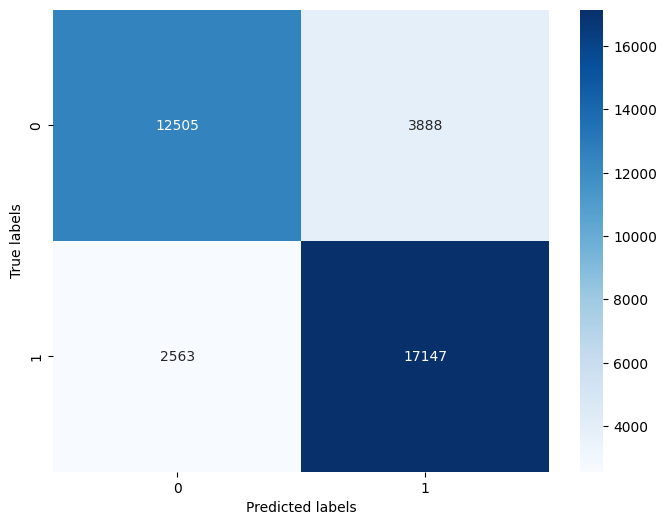

In [62]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

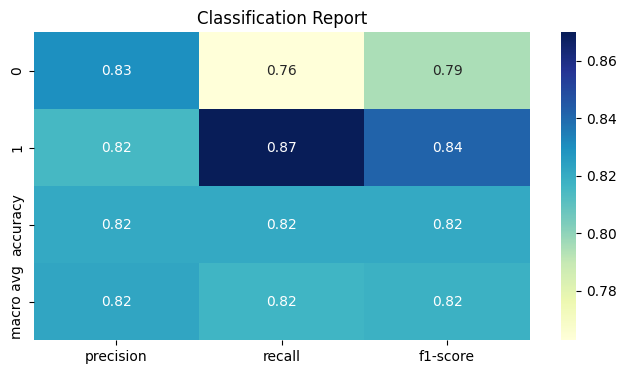

In [63]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

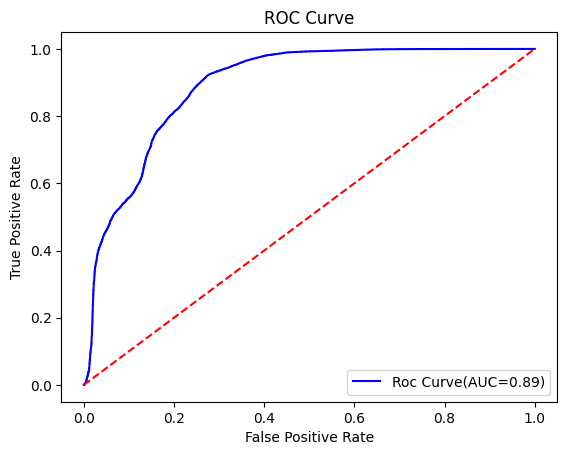

AUC Score: 0.8909185941221833


In [64]:
from sklearn.metrics import roc_curve,auc,roc_auc_score 
import matplotlib.pyplot as precision_recall_fscore_support

y_pred_proba=softmax_model.predict_proba(X_test)[:,1]

fpr,tpr,threshold=roc_curve(y_test,y_pred_proba)

auc_value=auc(fpr,tpr)

plt.plot(fpr,tpr,color='blue',label=f'Roc Curve(AUC={auc_value:.2f})')
plt.plot([0,1],[0,1],color='red',linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
print("AUC Score:",roc_auc_score(y_test,y_pred_proba))

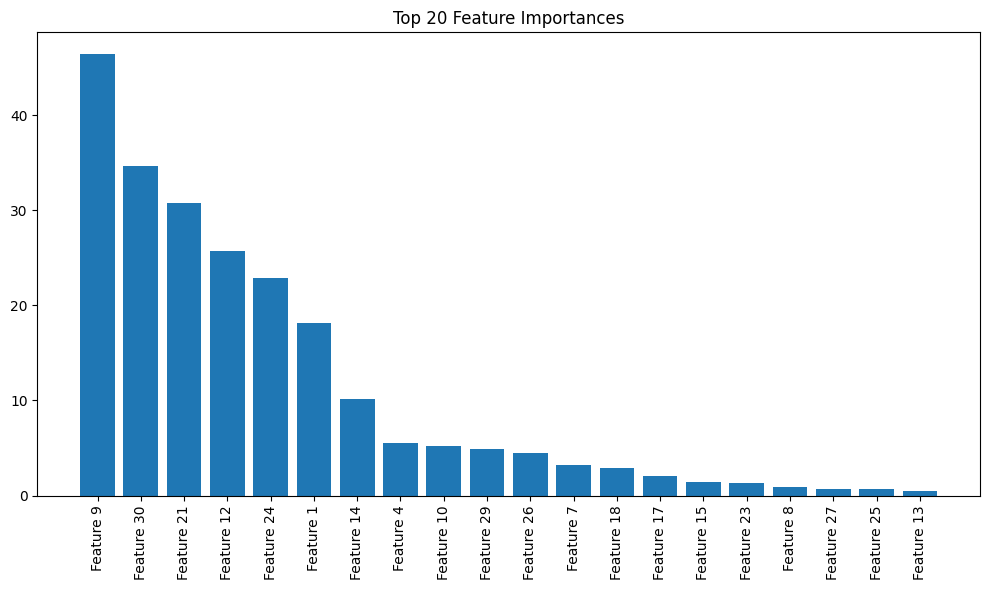

In [65]:
import numpy as np
import matplotlib.pyplot as plt

coefficients = softmax_model.coef_[0]  # For binary classification
feature_indices = np.argsort(np.abs(coefficients))[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(20), np.abs(coefficients[feature_indices[:20]]))
plt.xticks(range(20), [f'Feature {i}' for i in feature_indices[:20]], rotation=90)
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()


In [66]:
'''import shap

explainer = shap.Explainer(softmax_model.predict, X_train)
shap_values = explainer(X_test)

# Plot summary
shap.summary_plot(shap_values, X_test, plot_type='bar')'''


"import shap\n\nexplainer = shap.Explainer(softmax_model.predict, X_train)\nshap_values = explainer(X_test)\n\n# Plot summary\nshap.summary_plot(shap_values, X_test, plot_type='bar')"

In [67]:
from sklearn.metrics import confusion_matrix,classification_report,matthews_corrcoef,cohen_kappa_score,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test,y_pred)
report=classification_report(y_test,y_pred)
mcc=matthews_corrcoef(y_test,y_pred)
kappa=cohen_kappa_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

In [68]:
tn,fp,fn,tp=cm.ravel()

In [69]:
fpr=fp/(fp+tn)
fnr=fn/(fn+tp)

In [70]:
tn,fp,fn,tp

(12505, 3888, 2563, 17147)

In [71]:
mcc,kappa,precision,recall,f1,fpr,fnr

(0.6389003570327603,
 0.6371232916870149,
 0.8151652008557166,
 0.8699644850329782,
 0.8416738250092036,
 0.23717440370890014,
 0.13003551496702181)

In [72]:
#rf

In [73]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)  # features_train from LSTM on training set

# Predict on test features
y_pred = rf.predict(X_test)

# Evaluate
print("testing Accuracy:", accuracy_score(y_test, y_pred))

testing Accuracy: 0.9978672132509764


In [74]:
y_pred_train = rf.predict(X_train)

# Evaluate
print("training Accuracy:", accuracy_score(y_train, y_pred_train))

training Accuracy: 1.0


In [75]:
y_pred_val = rf.predict(X_val)

# Evaluate
print("validation Accuracy:", accuracy_score(y_val, y_pred_val))

validation Accuracy: 0.9967315735534443


In [76]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16393
           1       1.00      1.00      1.00     19710

    accuracy                           1.00     36103
   macro avg       1.00      1.00      1.00     36103
weighted avg       1.00      1.00      1.00     36103



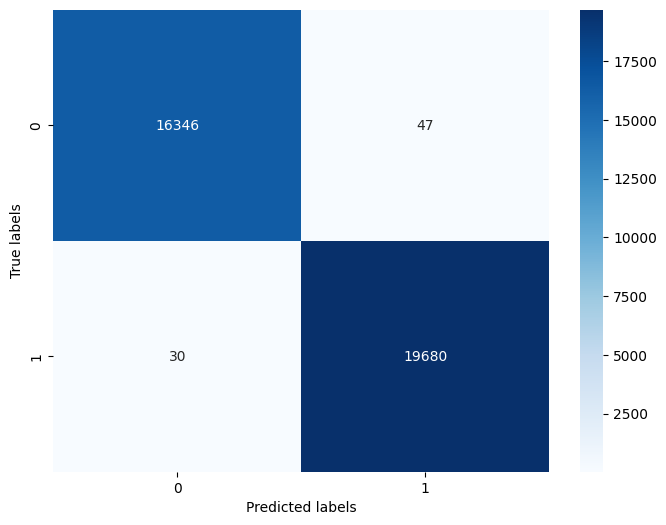

In [77]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

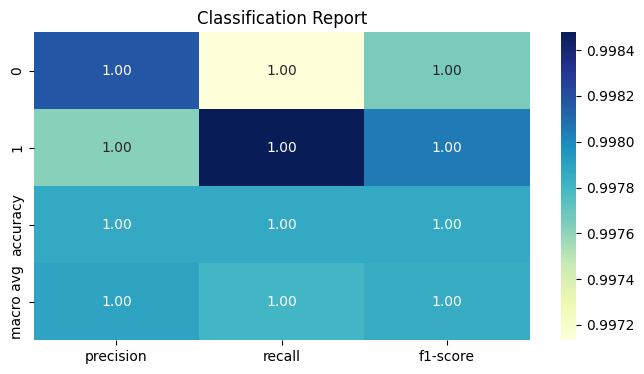

In [78]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

In [79]:
X_fe=X_features.reshape(X_features.shape[0],-1)

In [80]:
X_fe.shape ,y.shape 

((180515, 32), (180515,))

In [81]:
#5fold cross validation for rf
from sklearn.model_selection import KFold
kf=KFold(n_splits=5,shuffle=True,random_state=42)
accuracy_list=[]

for train_index,test_index in kf.split(X_fe):
    X_tr,X_te=X_fe[train_index],X_fe[test_index]
    y_tr,y_te=np.array(y)[train_index],np.array(y)[test_index]
    rf.fit(X_tr,y_tr)
    y_pred=rf.predict(X_te)
    accuracy=accuracy_score(y_te,y_pred)
    accuracy_list.append(accuracy)

for i,accuracy in enumerate(accuracy_list):
    print(f'Fold{i+1}:Accuracy={accuracy:.4f}')

print(f'Average Accuracy:{np.mean(accuracy_list):.4f}')



Fold1:Accuracy=0.9982
Fold2:Accuracy=0.9977
Fold3:Accuracy=0.9983
Fold4:Accuracy=0.9979
Fold5:Accuracy=0.9979
Average Accuracy:0.9980


In [82]:
#After Five Folding cross validation
y_pred_train = rf.predict(X_train)

# Evaluate
print("training Accuracy:", accuracy_score(y_train, y_pred_train))

training Accuracy: 0.9992983039267281


In [83]:
y_pred = rf.predict(X_test)

# Evaluate
print("testing Accuracy:", accuracy_score(y_test, y_pred))

testing Accuracy: 1.0


In [84]:
y_pred_val = rf.predict(X_val)

# Evaluate
print("validation Accuracy:", accuracy_score(y_val, y_pred_val))

validation Accuracy: 1.0


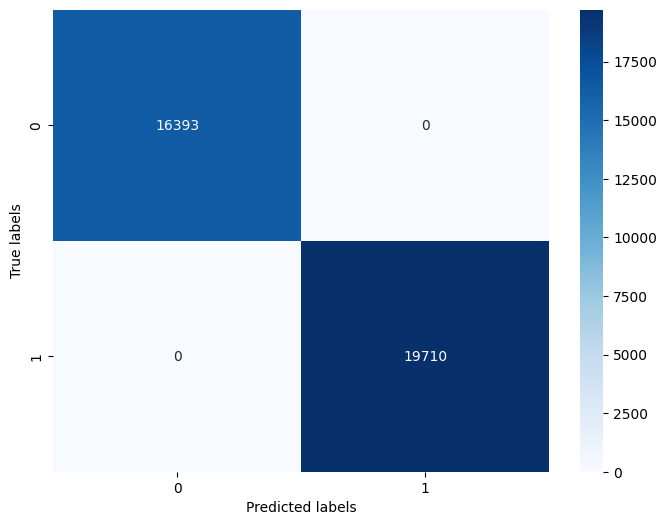

In [85]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

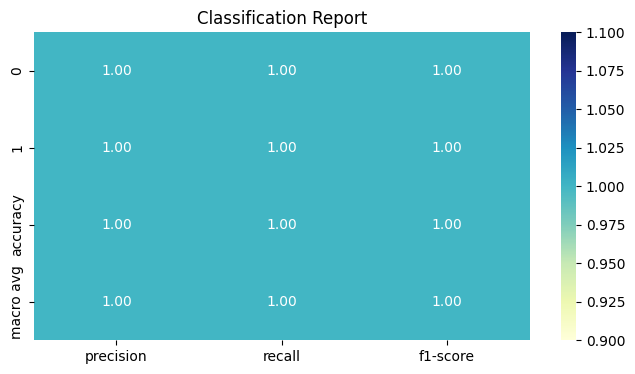

In [86]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

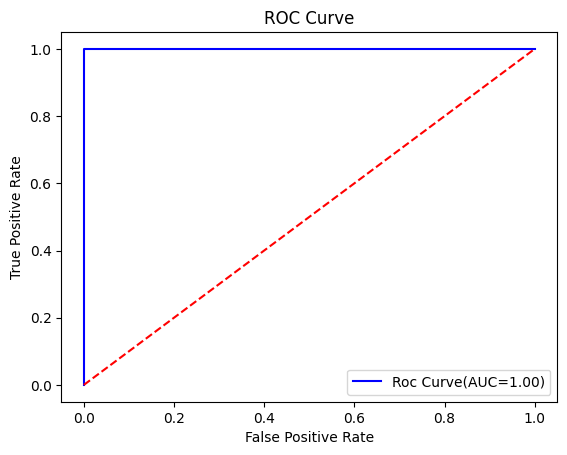

AUC Score: 1.0


In [87]:
from sklearn.metrics import roc_curve,auc,roc_auc_score 
import matplotlib.pyplot as precision_recall_fscore_support

y_pred_proba=rf.predict_proba(X_test)[:,1]

fpr,tpr,threshold=roc_curve(y_test,y_pred_proba)

auc_value=auc(fpr,tpr)

plt.plot(fpr,tpr,color='blue',label=f'Roc Curve(AUC={auc_value:.2f})')
plt.plot([0,1],[0,1],color='red',linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
print("AUC Score:",roc_auc_score(y_test,y_pred_proba))

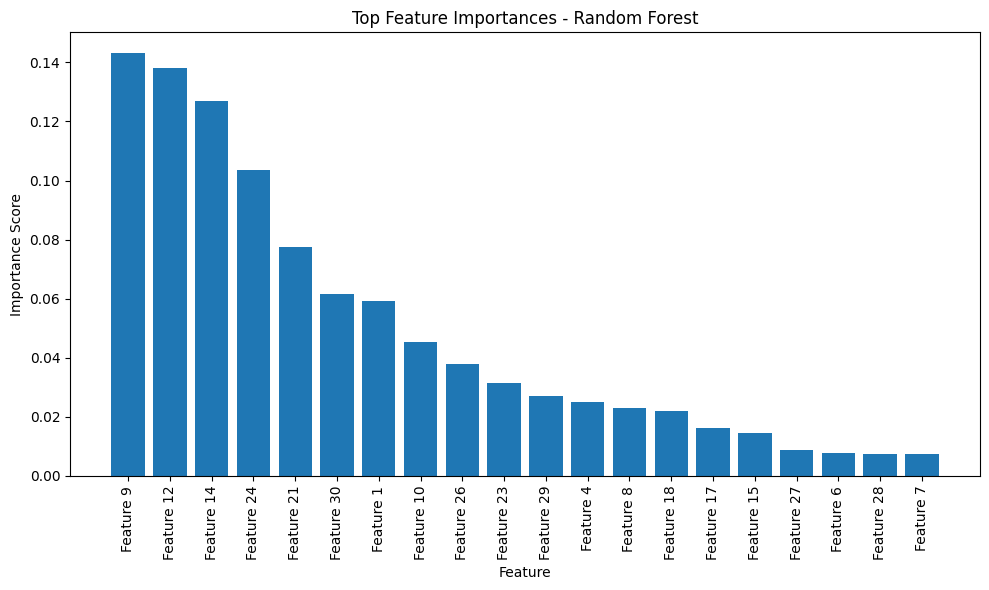

In [88]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances
importances = rf.feature_importances_  # assuming rf_model is your trained model

# Sort the feature importances
indices = np.argsort(importances)[::-1]

# Plot top N features (e.g., top 20)
plt.figure(figsize=(10, 6))
plt.title("Top Feature Importances - Random Forest")
plt.bar(range(20), importances[indices[:20]], align='center')
plt.xticks(range(20), [f'Feature {i}' for i in indices[:20]], rotation=90)
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()


In [89]:
'''import shap

explainer = shap.Explainer(rf.predict, X_train)
shap_values = explainer(X_test)

# Plot summary
shap.summary_plot(shap_values, X_test, plot_type='bar')
'''

"import shap\n\nexplainer = shap.Explainer(rf.predict, X_train)\nshap_values = explainer(X_test)\n\n# Plot summary\nshap.summary_plot(shap_values, X_test, plot_type='bar')\n"

In [90]:
from sklearn.metrics import confusion_matrix,classification_report,matthews_corrcoef,cohen_kappa_score,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test,y_pred)
report=classification_report(y_test,y_pred)
mcc=matthews_corrcoef(y_test,y_pred)
kappa=cohen_kappa_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

In [91]:
tn,fp,fn,tp=cm.ravel()

In [92]:
fpr=fp/(fp+tn)
fnr=fn/(fn+tp)

In [93]:
tn,fp,fn,tp

(16393, 0, 0, 19710)

In [94]:
mcc,kappa,precision,recall,f1,fpr,fnr

(1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0)

In [95]:
#svm

In [96]:
from sklearn.svm import SVC
svm_model=SVC(kernel='rbf', random_state=42,probability=True)
svm_model.fit(X_train,y_train)

SVC(probability=True, random_state=42)

In [97]:
y_pred=svm_model.predict(X_test)

In [98]:
y_pred

array([0, 1, 1, ..., 0, 1, 1], dtype=int64)

In [99]:
print("testing Accuracy:", accuracy_score(y_test,y_pred))

testing Accuracy: 0.9849596986400022


In [100]:
y_pred_train=svm_model.predict(X_train)
print("training Accuracy:", accuracy_score(y_train,y_pred_train))

training Accuracy: 0.9862338309835748


In [101]:
y_pred_val=svm_model.predict(X_val)
print("validation Accuracy:", accuracy_score(y_val,y_pred_val))

validation Accuracy: 0.9860953383375343


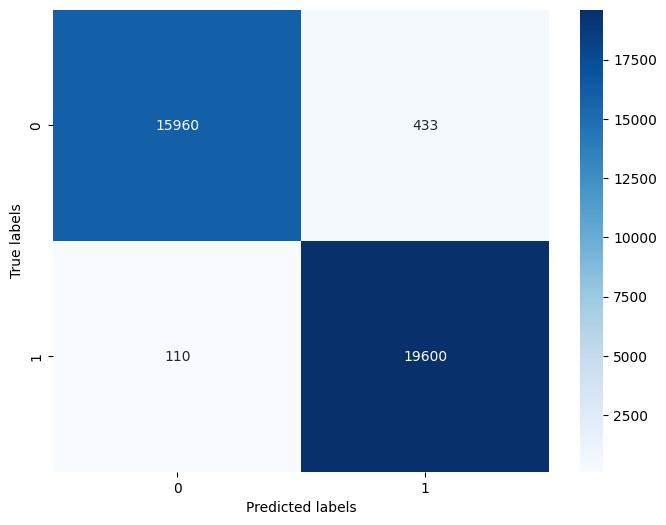

In [102]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

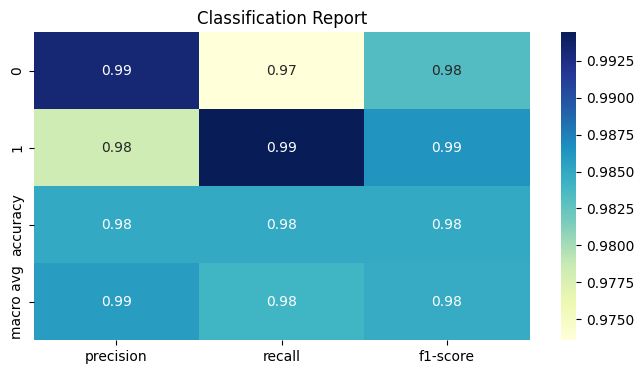

In [103]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

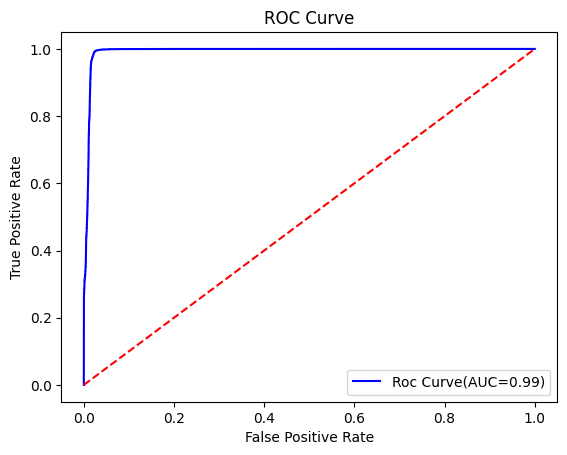

AUC Score: 0.9928171040323821


In [104]:
from sklearn.metrics import roc_curve,auc,roc_auc_score 
import matplotlib.pyplot as precision_recall_fscore_support

y_pred_proba=svm_model.predict_proba(X_test)[:,1]

fpr,tpr,threshold=roc_curve(y_test,y_pred_proba)

auc_value=auc(fpr,tpr)

plt.plot(fpr,tpr,color='blue',label=f'Roc Curve(AUC={auc_value:.2f})')
plt.plot([0,1],[0,1],color='red',linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
print("AUC Score:",roc_auc_score(y_test,y_pred_proba))

In [105]:
'''from sklearn.inspection import permutation_importance

result = permutation_importance(svm_model, X_test, y_test, n_repeats=10, random_state=42)
importance = result.importances_mean

# Plot top 20 features
indices = np.argsort(importance)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(20), importance[indices[:20]])
plt.xticks(range(20), [f'Feature {i}' for i in indices[:20]], rotation=90)
plt.title('Permutation Feature Importance for SVM')
plt.tight_layout()
plt.show()'''

"from sklearn.inspection import permutation_importance\n\nresult = permutation_importance(svm_model, X_test, y_test, n_repeats=10, random_state=42)\nimportance = result.importances_mean\n\n# Plot top 20 features\nindices = np.argsort(importance)[::-1]\n\nplt.figure(figsize=(10, 6))\nplt.bar(range(20), importance[indices[:20]])\nplt.xticks(range(20), [f'Feature {i}' for i in indices[:20]], rotation=90)\nplt.title('Permutation Feature Importance for SVM')\nplt.tight_layout()\nplt.show()"

In [106]:
'''import shap

explainer = shap.Explainer(softmax_model.predict, X_train)
shap_values = explainer(X_test)

# Plot summary
shap.summary_plot(shap_values, X_test, plot_type='bar')'''

"import shap\n\nexplainer = shap.Explainer(softmax_model.predict, X_train)\nshap_values = explainer(X_test)\n\n# Plot summary\nshap.summary_plot(shap_values, X_test, plot_type='bar')"

In [107]:
from sklearn.metrics import confusion_matrix,classification_report,matthews_corrcoef,cohen_kappa_score,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test,y_pred)
report=classification_report(y_test,y_pred)
mcc=matthews_corrcoef(y_test,y_pred)
kappa=cohen_kappa_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

In [108]:
tn,fp,fn,tp=cm.ravel()

In [109]:
fpr=fp/(fp+tn)
fnr=fn/(fn+tp)

In [110]:
tn,fp,fn,tp

(15960, 433, 110, 19600)

In [111]:
mcc,kappa,precision,recall,f1,fpr,fnr

(0.969771376159027,
 0.9696129387868431,
 0.9783856636549693,
 0.9944190766108574,
 0.9863372166167627,
 0.026413713170255596,
 0.005580923389142567)

In [112]:
#KNN

In [113]:
from sklearn.neighbors import KNeighborsClassifier
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train,y_train)

KNeighborsClassifier()

In [114]:
y_pred=knn_model.predict(X_test)
print("testing Accuracy:", accuracy_score(y_test,y_pred))

testing Accuracy: 0.9958729191479933


In [115]:
y_pred_train=knn_model.predict(X_train)
print("training Accuracy:", accuracy_score(y_train,y_pred_train))

training Accuracy: 0.9977471862910746


In [116]:
y_pred_val=knn_model.predict(X_val)
print("validation Accuracy:", accuracy_score(y_val,y_pred_val))

validation Accuracy: 0.9960945073816581


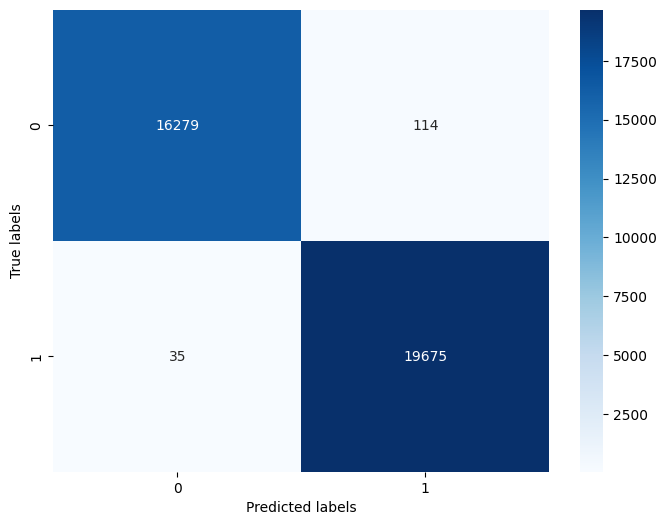

In [117]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

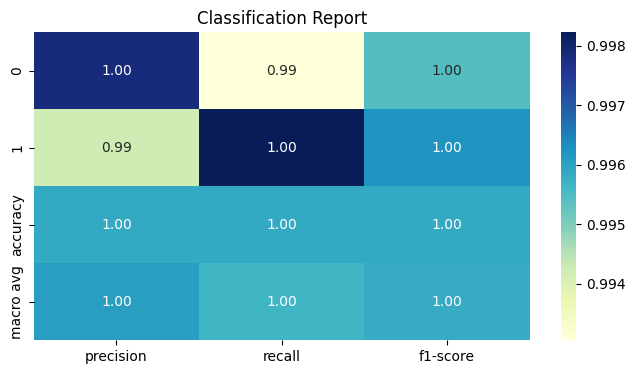

In [118]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

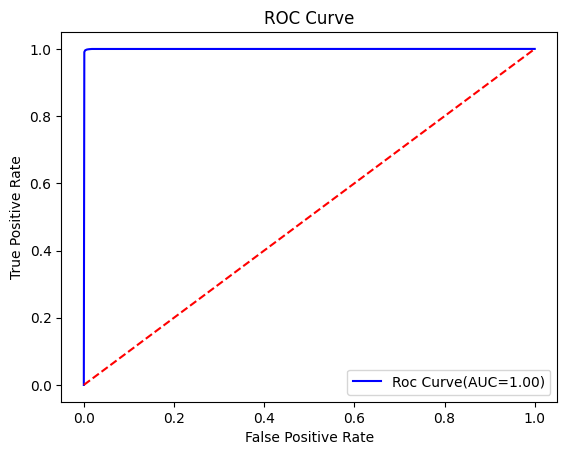

AUC Score: 0.9993380346383508


In [119]:
from sklearn.metrics import roc_curve,auc,roc_auc_score 
import matplotlib.pyplot as precision_recall_fscore_support

y_pred_proba=knn_model.predict_proba(X_test)[:,1]

fpr,tpr,threshold=roc_curve(y_test,y_pred_proba)

auc_value=auc(fpr,tpr)

plt.plot(fpr,tpr,color='blue',label=f'Roc Curve(AUC={auc_value:.2f})')
plt.plot([0,1],[0,1],color='red',linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
print("AUC Score:",roc_auc_score(y_test,y_pred_proba))

In [120]:
'''import shap

explainer = shap.Explainer(softmax_model.predict, X_train)
shap_values = explainer(X_test)

# Plot summary
shap.summary_plot(shap_values, X_test, plot_type='bar')'''

"import shap\n\nexplainer = shap.Explainer(softmax_model.predict, X_train)\nshap_values = explainer(X_test)\n\n# Plot summary\nshap.summary_plot(shap_values, X_test, plot_type='bar')"

In [121]:
from sklearn.metrics import confusion_matrix,classification_report,matthews_corrcoef,cohen_kappa_score,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test,y_pred)
report=classification_report(y_test,y_pred)
mcc=matthews_corrcoef(y_test,y_pred)
kappa=cohen_kappa_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

In [122]:
tn,fp,fn,tp=cm.ravel()

In [123]:
fpr=fp/(fp+tn)
fnr=fn/(fn+tp)

In [124]:
tn,fp,fn,tp

(16279, 114, 35, 19675)

In [125]:
mcc,kappa,precision,recall,f1,fpr,fnr

(0.9916818600178418,
 0.9916721931133566,
 0.9942392238112082,
 0.9982242516489092,
 0.9962277526013317,
 0.006954187763069603,
 0.0017757483510908167)

In [126]:
#Random trees

In [127]:
from sklearn.ensemble import ExtraTreesClassifier 

et_model=ExtraTreesClassifier(n_estimators=100,random_state=42)

In [128]:
et_model.fit(X_train,y_train)

ExtraTreesClassifier(random_state=42)

In [129]:
y_pred=et_model.predict(X_test)
print("testing Accuracy:", accuracy_score(y_test,y_pred))

testing Accuracy: 0.9981165000138492


In [130]:
y_pred_train=et_model.predict(X_train)
print("training Accuracy:", accuracy_score(y_train,y_pred_train))

training Accuracy: 1.0


In [131]:
y_pred_val=et_model.predict(X_val)
print("validation Accuracy:", accuracy_score(y_val,y_pred_val))

validation Accuracy: 0.9977564191341439


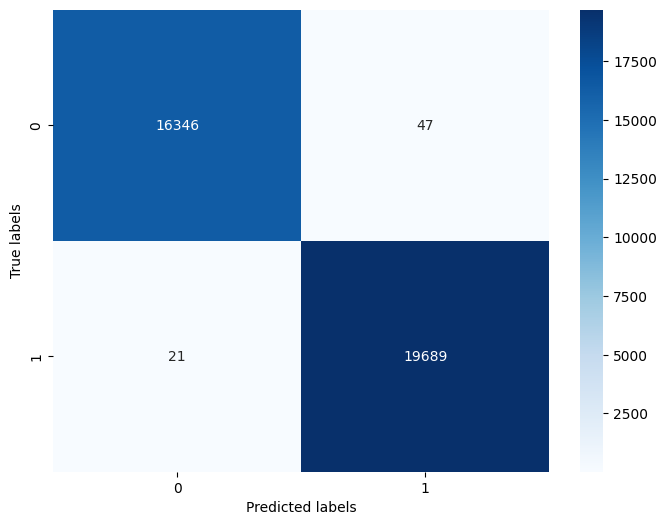

In [132]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

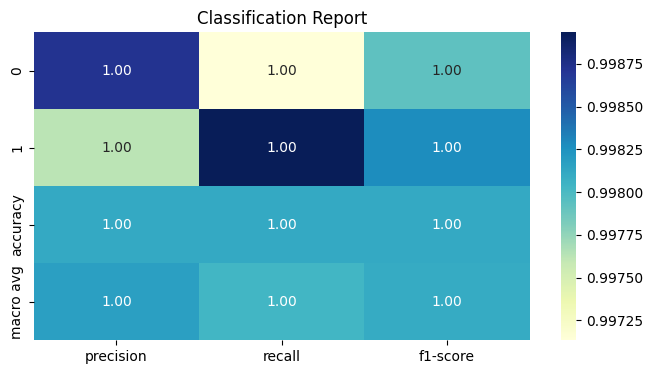

In [133]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

In [134]:
#5fold cross validation for rf
from sklearn.model_selection import KFold
kf=KFold(n_splits=5,shuffle=True,random_state=42)
accuracy_list=[]

for train_index,test_index in kf.split(X_fe):
    X_tr,X_te=X_fe[train_index],X_fe[test_index]
    y_tr,y_te=np.array(y)[train_index],np.array(y)[test_index]
    et_model.fit(X_tr,y_tr)
    y_pred=et_model.predict(X_te)
    accuracy=accuracy_score(y_te,y_pred)
    accuracy_list.append(accuracy)

for i,accuracy in enumerate(accuracy_list):
    print(f'Fold{i+1}:Accuracy={accuracy:.4f}')

print(f'Average Accuracy:{np.mean(accuracy_list):.4f}')



Fold1:Accuracy=0.9987
Fold2:Accuracy=0.9984
Fold3:Accuracy=0.9988
Fold4:Accuracy=0.9983
Fold5:Accuracy=0.9983
Average Accuracy:0.9985


In [135]:
#After Five Folding cross validation
y_pred_train = et_model.predict(X_train)

# Evaluate
print("training Accuracy:", accuracy_score(y_train, y_pred_train))

training Accuracy: 0.9994183308866299


In [136]:
y_pred = et_model.predict(X_test)

# Evaluate
print("testing Accuracy:", accuracy_score(y_test, y_pred))

testing Accuracy: 1.0


In [137]:
y_pred_val = et_model.predict(X_val)

# Evaluate
print("validation Accuracy:", accuracy_score(y_val, y_pred_val))

validation Accuracy: 1.0


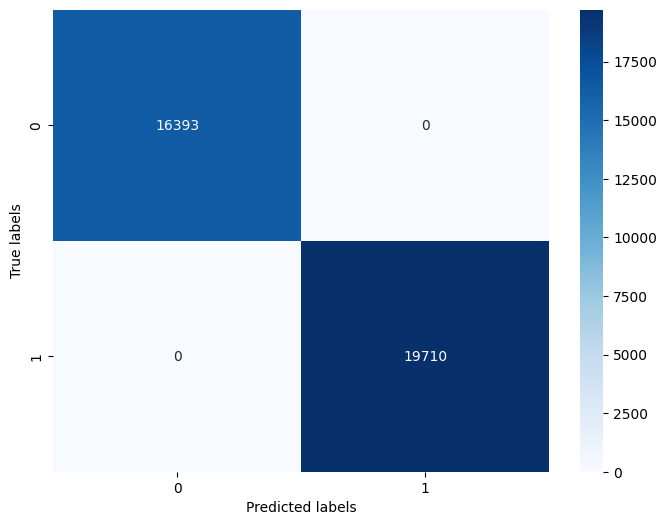

In [138]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

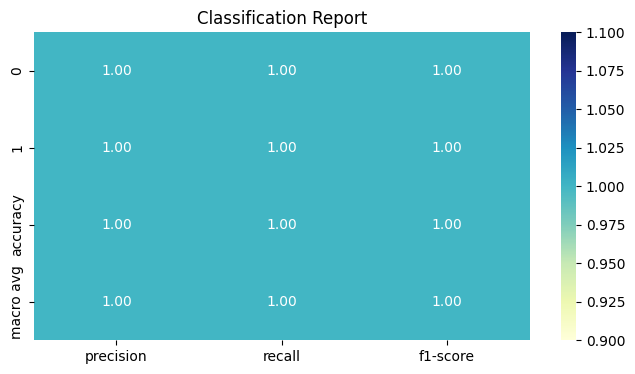

In [139]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

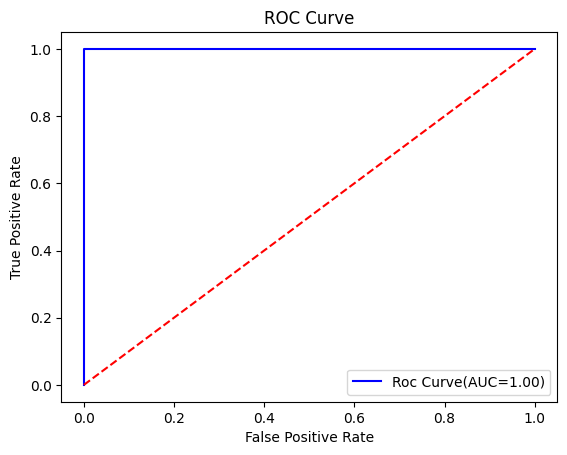

AUC Score: 1.0


In [140]:
from sklearn.metrics import roc_curve,auc,roc_auc_score 
import matplotlib.pyplot as precision_recall_fscore_support

y_pred_proba=et_model.predict_proba(X_test)[:,1]

fpr,tpr,threshold=roc_curve(y_test,y_pred_proba)

auc_value=auc(fpr,tpr)

plt.plot(fpr,tpr,color='blue',label=f'Roc Curve(AUC={auc_value:.2f})')
plt.plot([0,1],[0,1],color='red',linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
print("AUC Score:",roc_auc_score(y_test,y_pred_proba))

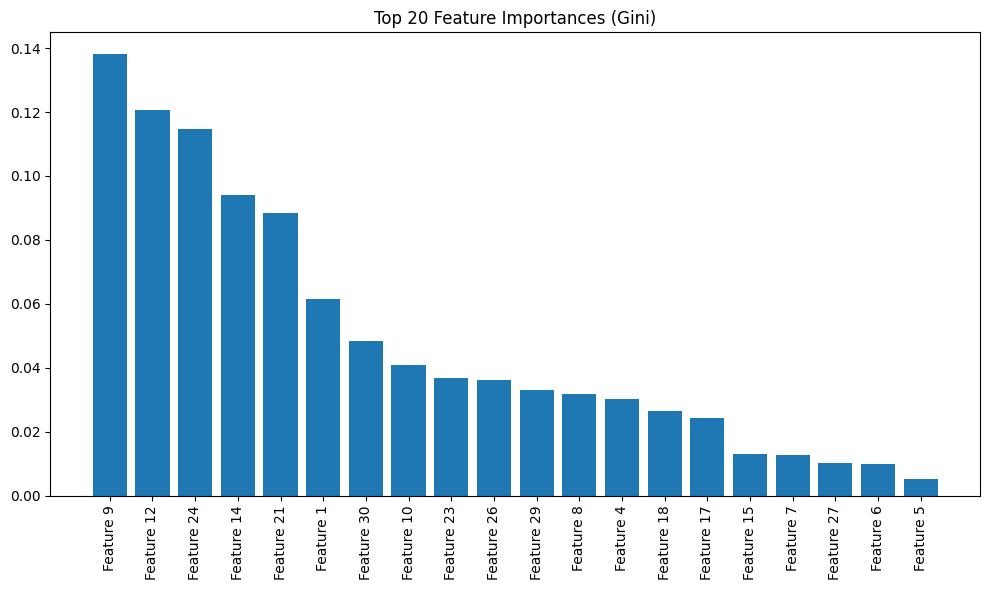

In [141]:
import matplotlib.pyplot as plt
import numpy as np

# Random should be trained already
importances = et_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Top 20 Feature Importances (Gini)")
plt.bar(range(20), importances[indices[:20]], align='center')
plt.xticks(range(20), [f"Feature {i}" for i in indices[:20]], rotation=90)
plt.tight_layout()
plt.show()


In [142]:
from sklearn.metrics import confusion_matrix,classification_report,matthews_corrcoef,cohen_kappa_score,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test,y_pred)
report=classification_report(y_test,y_pred)
mcc=matthews_corrcoef(y_test,y_pred)
kappa=cohen_kappa_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

In [143]:
tn,fp,fn,tp=cm.ravel()

In [144]:
fpr=fp/(fp+tn)
fnr=fn/(fn+tp)

In [145]:
tn,fp,fn,tp

(16393, 0, 0, 19710)

In [146]:
mcc,kappa,precision,recall,f1,fpr,fnr

(1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0)

In [147]:
'''from sklearn.model_selection import GridSearchCV
param_grid={'n_estimators':[10,50,100],'max_depth':[None,5,10]}
grid_search=GridSearchCV(et_model,param_grid,cv=5)
grid_search.fit(X_train,y_train)
print("Best parameters:" ,grid_search.best_params_)
print("Best score:",grid_search.best_score_)'''

'from sklearn.model_selection import GridSearchCV\nparam_grid={\'n_estimators\':[10,50,100],\'max_depth\':[None,5,10]}\ngrid_search=GridSearchCV(et_model,param_grid,cv=5)\ngrid_search.fit(X_train,y_train)\nprint("Best parameters:" ,grid_search.best_params_)\nprint("Best score:",grid_search.best_score_)'

In [148]:
'''best_model=grid_search.best_estimator_
best_model.fit(X_train,y_train)'''

'best_model=grid_search.best_estimator_\nbest_model.fit(X_train,y_train)'

In [149]:
'''y_pred_grid=best_model.predict(X_test)
print("Testing accuracy after grid search:",accuracy_score(y_test,y_pred_grid))'''

'y_pred_grid=best_model.predict(X_test)\nprint("Testing accuracy after grid search:",accuracy_score(y_test,y_pred_grid))'

In [150]:
'''y_pred_grid_train=best_model.predict(X_train)
print("Training accuracy after grid search:",accuracy_score(y_train,y_pred_grid_train))'''

'y_pred_grid_train=best_model.predict(X_train)\nprint("Training accuracy after grid search:",accuracy_score(y_train,y_pred_grid_train))'

In [151]:
#decision tree

In [152]:
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier(random_state=42)

In [153]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [154]:
y_pred=dt_model.predict(X_test)
print("testing Accuracy:", accuracy_score(y_test,y_pred))

testing Accuracy: 0.9878403456776446


In [155]:
y_pred_train=dt_model.predict(X_train)
print("training Accuracy:", accuracy_score(y_train,y_pred_train))

training Accuracy: 1.0


In [156]:
y_pred_val=dt_model.predict(X_val)
print("validation Accuracy:", accuracy_score(y_val,y_pred_val))

validation Accuracy: 0.9875910589147716


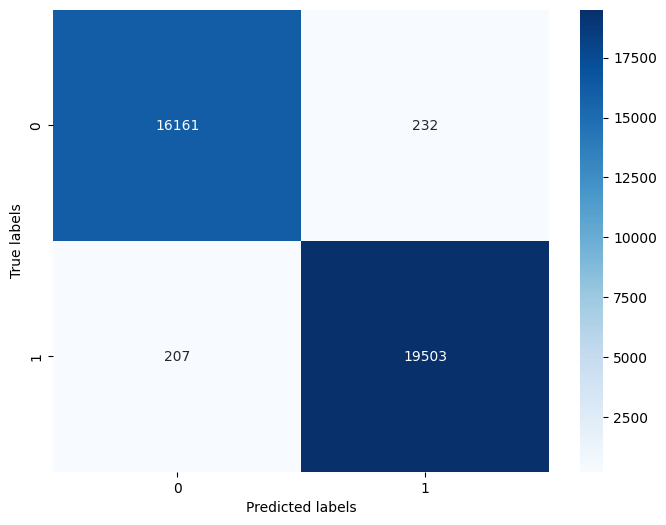

In [157]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

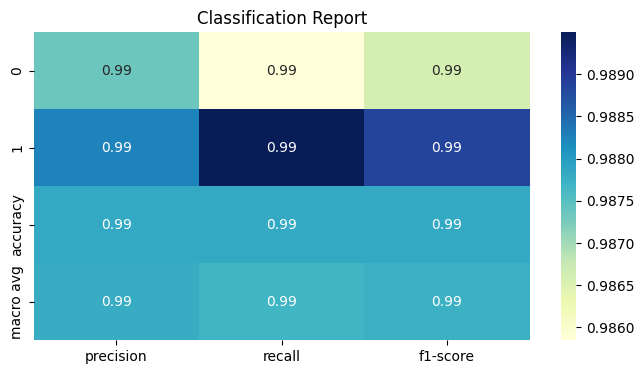

In [158]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

In [159]:
#5fold cross validation for rf
from sklearn.model_selection import KFold
kf=KFold(n_splits=5,shuffle=True,random_state=42)
accuracy_list=[]

for train_index,test_index in kf.split(X_fe):
    X_tr,X_te=X_fe[train_index],X_fe[test_index]
    y_tr,y_te=np.array(y)[train_index],np.array(y)[test_index]
    dt_model.fit(X_tr,y_tr)
    y_pred=dt_model.predict(X_te)
    accuracy=accuracy_score(y_te,y_pred)
    accuracy_list.append(accuracy)

for i,accuracy in enumerate(accuracy_list):
    print(f'Fold{i+1}:Accuracy={accuracy:.4f}')

print(f'Average Accuracy:{np.mean(accuracy_list):.4f}')


Fold1:Accuracy=0.9900
Fold2:Accuracy=0.9907
Fold3:Accuracy=0.9910
Fold4:Accuracy=0.9900
Fold5:Accuracy=0.9905
Average Accuracy:0.9904


In [160]:
#After Five Folding cross validation
y_pred_train = dt_model.predict(X_train)

# Evaluate
print("training Accuracy:", accuracy_score(y_train, y_pred_train))

training Accuracy: 0.9968423676702767


In [161]:
y_pred = dt_model.predict(X_test)

# Evaluate
print("testing Accuracy:", accuracy_score(y_test, y_pred))

testing Accuracy: 1.0


In [162]:
y_pred_val = dt_model.predict(X_val)

# Evaluate
print("validation Accuracy:", accuracy_score(y_val, y_pred_val))

validation Accuracy: 1.0


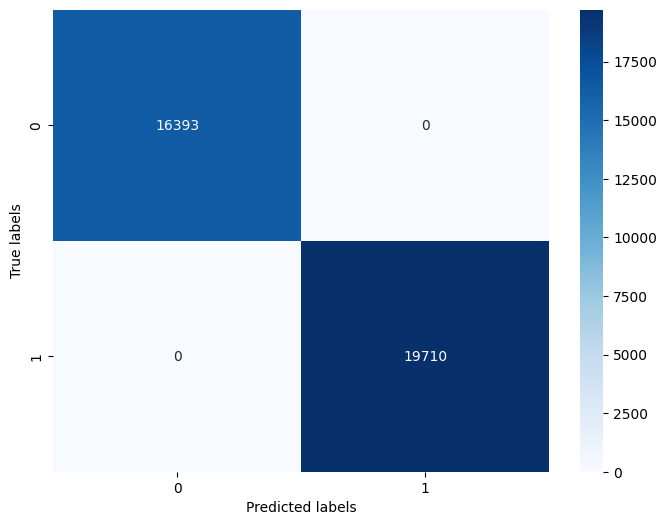

In [163]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

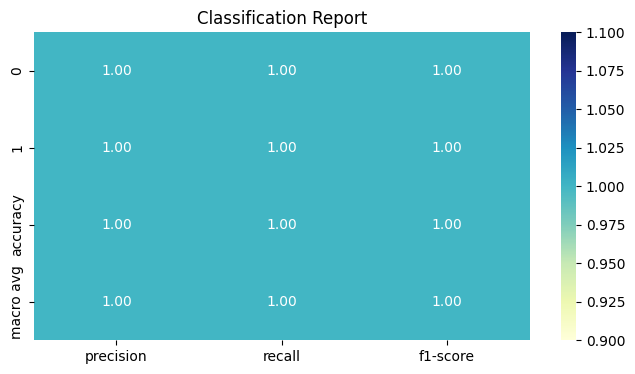

In [164]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

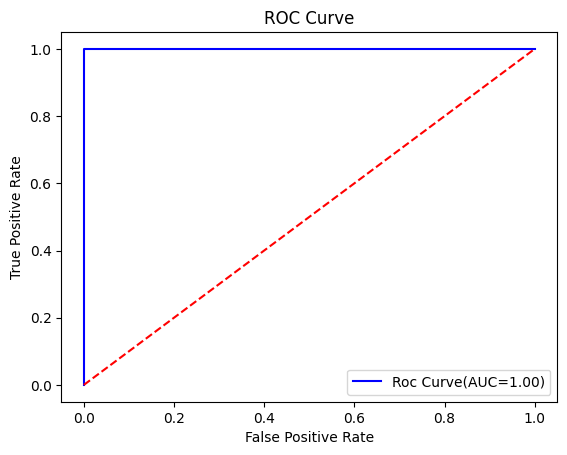

AUC Score: 1.0


In [165]:
from sklearn.metrics import roc_curve,auc,roc_auc_score 
import matplotlib.pyplot as precision_recall_fscore_support

y_pred_proba=dt_model.predict_proba(X_test)[:,1]

fpr,tpr,threshold=roc_curve(y_test,y_pred_proba)

auc_value=auc(fpr,tpr)

plt.plot(fpr,tpr,color='blue',label=f'Roc Curve(AUC={auc_value:.2f})')
plt.plot([0,1],[0,1],color='red',linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
print("AUC Score:",roc_auc_score(y_test,y_pred_proba))

In [166]:
from sklearn.metrics import confusion_matrix,classification_report,matthews_corrcoef,cohen_kappa_score,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test,y_pred)
report=classification_report(y_test,y_pred)
mcc=matthews_corrcoef(y_test,y_pred)
kappa=cohen_kappa_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

In [167]:
tn,fp,fn,tp=cm.ravel()

In [168]:
fpr=fp/(fp+tn)
fnr=fn/(fn+tp)

In [169]:
tn,fp,fn,tp

(16393, 0, 0, 19710)

In [170]:
mcc,kappa,precision,recall,f1,fpr,fnr

(1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0)

In [171]:
#mlp

In [172]:
from sklearn.neural_network import MLPClassifier
mlp=MLPClassifier(hidden_layer_sizes=(50,50),max_iter=1000,random_state=42)

In [173]:
mlp.fit(X_train,y_train)

MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=1000, random_state=42)

In [174]:
y_pred=mlp.predict(X_test)
print("testing Accuracy:", accuracy_score(y_test,y_pred))

testing Accuracy: 0.9779519707503531


In [175]:
y_pred_train=mlp.predict(X_train)
print("training Accuracy:", accuracy_score(y_train,y_pred_train))

training Accuracy: 0.9795030883860067


In [176]:
y_pred_val=mlp.predict(X_val)
print("validation Accuracy:", accuracy_score(y_val,y_pred_val))

validation Accuracy: 0.9783674486884747


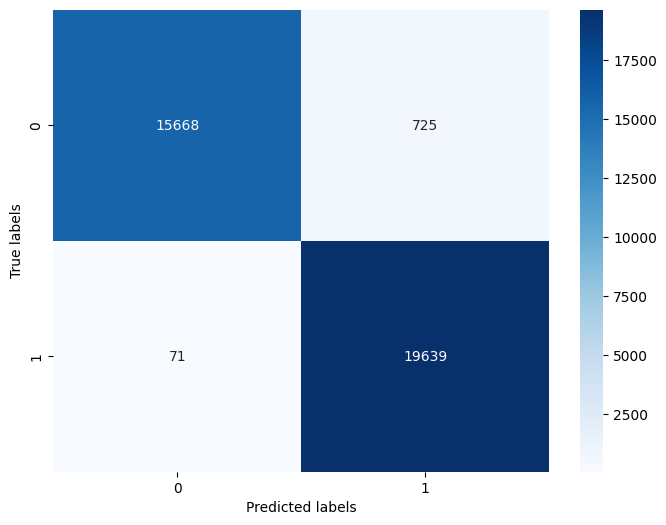

In [177]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

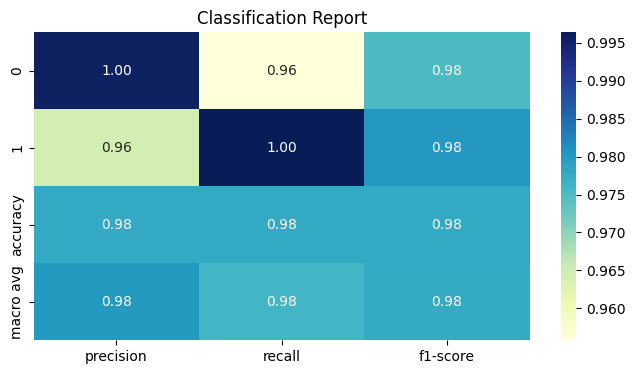

In [178]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

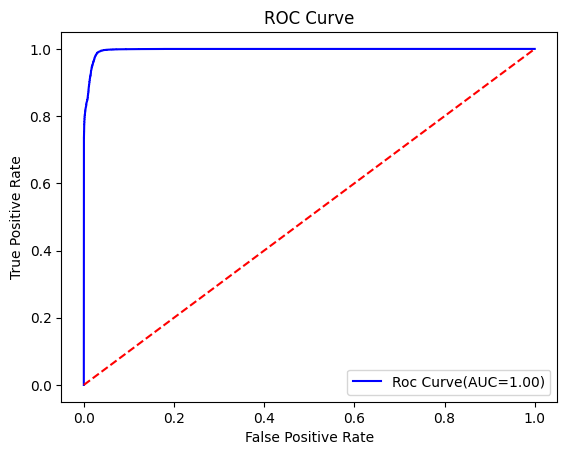

AUC Score: 0.9969639238859145


In [179]:
from sklearn.metrics import roc_curve,auc,roc_auc_score 
import matplotlib.pyplot as precision_recall_fscore_support

y_pred_proba=mlp.predict_proba(X_test)[:,1]

fpr,tpr,threshold=roc_curve(y_test,y_pred_proba)

auc_value=auc(fpr,tpr)

plt.plot(fpr,tpr,color='blue',label=f'Roc Curve(AUC={auc_value:.2f})')
plt.plot([0,1],[0,1],color='red',linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
print("AUC Score:",roc_auc_score(y_test,y_pred_proba))

In [180]:
from sklearn.metrics import confusion_matrix,classification_report,matthews_corrcoef,cohen_kappa_score,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test,y_pred)
report=classification_report(y_test,y_pred)
mcc=matthews_corrcoef(y_test,y_pred)
kappa=cohen_kappa_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

In [181]:
tn,fp,fn,tp=cm.ravel()

In [182]:
tn,fp,fn,tp

(15668, 725, 71, 19639)

In [183]:
fpr=fp/(fp+tn)
fnr=fn/(fn+tp)

In [184]:
mcc,kappa,precision,recall,f1,fpr,fnr

(0.9560214388181073,
 0.955378756523585,
 0.9643979571793361,
 0.9963977676306444,
 0.9801367470180167,
 0.04422619410724089,
 0.003602232369355657)

In [185]:
#ROC comparing

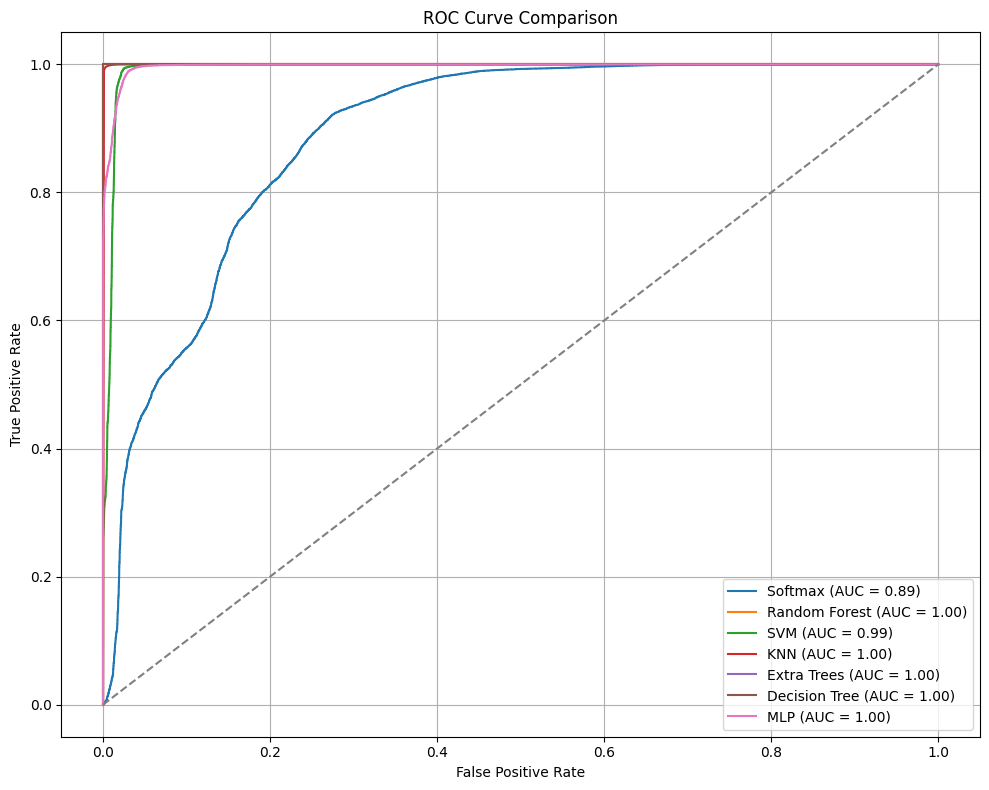

In [186]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

models = {
    "Softmax": softmax_model,
    "Random Forest": rf,
    "SVM": svm_model,
    "KNN": knn_model,
    "Extra Trees": et_model,
    "Decision Tree": dt_model,
    "MLP": mlp
}

plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Get predicted probabilities
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]  # Probability for class 1
    elif hasattr(model, "decision_function"):
        # For some SVMs
        y_proba = model.decision_function(X_test)
    else:
        print(f"Model {name} does not support probability prediction.")
        continue

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot random baseline
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.tight_layout()
plt.show()


In [187]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

def get_feature_importance(model, X_test, y_test, model_name):
    if model_name == 'Logistic Regression':
        return np.abs(model.coef_[0])

    elif model_name in ['Random Forest', 'Extra Trees', 'Decision Tree']:
        return model.feature_importances_

    elif model_name == 'SVM':
        if hasattr(model, 'coef_'):
            return np.abs(model.coef_[0])
        else:
            return None  # For non-linear SVMs

    elif model_name in ['KNN', 'MLP']:
        result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
        return result.importances_mean

    return None


In [188]:
def plot_feature_importances(models_dict, X_test, y_test, top_n=20):
    plt.figure(figsize=(20, 15))

    for idx, (name, model) in enumerate(models_dict.items()):
        importance = get_feature_importance(model, X_test, y_test, name)
        if importance is not None:
            indices = np.argsort(importance)[-top_n:][::-1]
            plt.subplot(3, 3, idx + 1)
            plt.bar(range(top_n), importance[indices])
            plt.xticks(range(top_n), [f'F{i}' for i in indices], rotation=90)
            plt.title(f'{name}')
        else:
            print(f"⚠️ Feature importance not available for: {name}")

    plt.tight_layout()
    plt.show()


⚠️ Feature importance not available for: SVM


KeyboardInterrupt: 

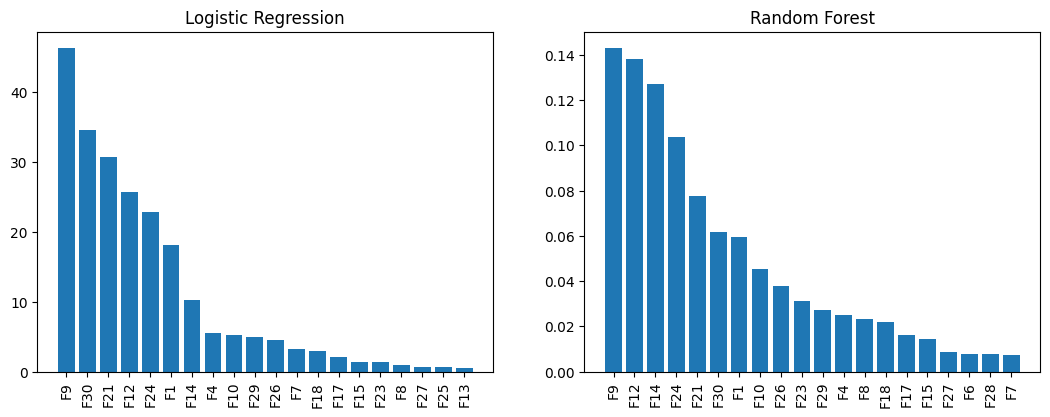

In [189]:
models = {
    'Logistic Regression': softmax_model,
    'Random Forest': rf,
    'SVM': svm_model,
    'KNN': knn_model,
    'Extra Trees': et_model,
    'Decision Tree': dt_model,
    'MLP': mlp
}

plot_feature_importances(models, X_test, y_test)
